In [1]:
#  Statistics Assignment



In [2]:
# 1. Generate a list of 100 integers containing values between 90 to 130 and store it in the variable `int_list`. After generating the list, find the following:

# (i) Write a Python function to calculate the mean of a given list of numbers. Create a function to find the median of a list of numbers.

# (ii) Develop a program to compute the mode of a list of integers.


# (iii) Implement a function to calculate the weighted mean of a list of values and their corresponding weights.

# (iv) Write a Python function to find the geometric mean of a list of positive numbers.


# (v) Create a program to calculate the harmonic mean of a list of values.

# (vi) Build a function to determine the midrange of a list of numbers (average of the minimum and maximum).

# (vii) Implement a Python program to find the trimmed mean of a list, excluding a certain percentage of outliers.


import random
import math
from collections import Counter
from typing import List, Tuple

# Generate the list
random.seed(0)  # for reproducibility; remove or change for fresh randomness
int_list = [random.randint(90, 130) for _ in range(100)]

# (i) Mean
def mean(nums: List[float]) -> float:
    return sum(nums) / len(nums) if nums else float('nan')

# (i) Median
def median(nums: List[float]) -> float:
    n = len(nums)
    if n == 0:
        return float('nan')
    s = sorted(nums)
    mid = n // 2
    if n % 2:
        return s[mid]
    else:
        return (s[mid - 1] + s[mid]) / 2

# (ii) Mode
def mode(nums: List[int]) -> List[int]:
    if not nums:
        return []
    counts = Counter(nums)
    max_count = max(counts.values())
    return [num for num, cnt in counts.items() if cnt == max_count]

# (iii) Weighted mean
def weighted_mean(values: List[float], weights: List[float]) -> float:
    if not values or not weights or len(values) != len(weights):
        raise ValueError("Lists must be of equal non-zero length")
    total_weight = sum(weights)
    if total_weight == 0:
        return float('nan')
    return sum(v * w for v, w in zip(values, weights)) / total_weight

# (iv) Geometric mean
def geometric_mean(nums: List[float]) -> float:
    if not nums or any(n <= 0 for n in nums):
        raise ValueError("List must contain only positive numbers")
    log_sum = sum(math.log(n) for n in nums)
    return math.exp(log_sum / len(nums))

# (v) Harmonic mean
def harmonic_mean(nums: List[float]) -> float:
    if not nums or any(n <= 0 for n in nums):
        raise ValueError("List must contain only positive numbers")
    return len(nums) / sum(1 / n for n in nums)

# (vi) Midrange
def midrange(nums: List[float]) -> float:
    if not nums:
        return float('nan')
    return (min(nums) + max(nums)) / 2

# (vii) Trimmed mean: exclude e.g. 10% lowest and highest by default
def trimmed_mean(nums: List[float], proportion_to_trim: float = 0.1) -> float:
    if not nums:
        return float('nan')
    if not 0 <= proportion_to_trim < 0.5:
        raise ValueError("Trim proportion must be between 0 and less than 0.5")
    s = sorted(nums)
    n = len(s)
    k = int(n * proportion_to_trim)
    trimmed = s[k:n - k]
    return mean(trimmed)

# Example usage with int_list:
if __name__ == "__main__":
    print("int_list:", int_list)
    print("Mean:", mean(int_list))
    print("Median:", median(int_list))
    print("Mode(s):", mode(int_list))

    # Example weights for demonstration (same length):
    weights = [random.uniform(0.1, 2.0) for _ in range(len(int_list))]
    print("Weighted Mean:", weighted_mean(int_list, weights))

    # Note: geometric and harmonic mean require positives:
    print("Geometric Mean:", geometric_mean(int_list))
    print("Harmonic Mean:", harmonic_mean(int_list))

    print("Midrange:", midrange(int_list))
    print("Trimmed Mean (10%):", trimmed_mean(int_list, 0.1))

int_list: [114, 116, 92, 106, 122, 121, 115, 109, 120, 112, 127, 103, 122, 98, 108, 98, 96, 129, 106, 124, 128, 99, 109, 96, 94, 111, 120, 125, 96, 112, 117, 110, 129, 130, 103, 125, 120, 118, 123, 106, 93, 125, 90, 95, 115, 130, 90, 129, 121, 111, 105, 110, 94, 102, 126, 104, 105, 99, 124, 118, 95, 95, 110, 122, 121, 96, 109, 125, 108, 97, 125, 111, 124, 103, 128, 125, 127, 108, 118, 95, 128, 114, 110, 126, 105, 108, 101, 102, 101, 92, 129, 106, 120, 94, 95, 98, 99, 92, 95, 124]
Mean: 110.76
Median: 110.0
Mode(s): [125, 95]
Weighted Mean: 110.32594447883659
Geometric Mean: 110.09195547260079
Harmonic Mean: 109.42156553528962
Midrange: 110.0
Trimmed Mean (10%): 110.7875


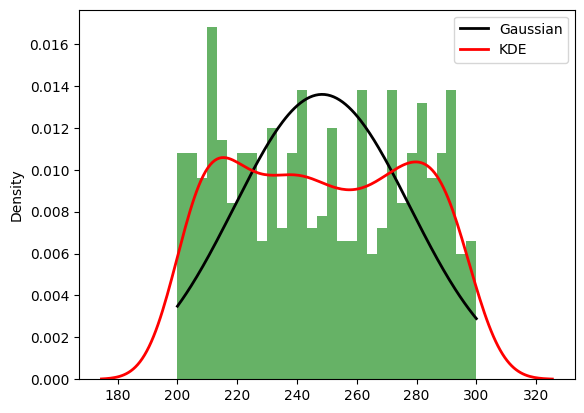

Range: 100
Sample variance: 862.5731462925852
Sample std deviation: 29.369595609960058
IQR: 53.0
Coefficient of variation: 0.11823508699661858
Mean absolute deviation: 25.6648
Quartile deviation: 26.5
Range-based coefficient of dispersion: 0.4024144869215292


In [3]:
# 2. Generate a list of 500 integers containing values between 200 to 300 and store it in the variable `int_list2`. After generating the list, find the following:

# (i) Compare the given list of visualization for the given data:

# 1. Frequency & Gaussian distribution

# 2. Frequency smoothened KDE plot

# 3. Gaussian distribution & smoothened KDE plot

# (ii) Write a Python function to calculate the range of a given list of numbers.

# (iii) Create a program to find the variance and standard deviation of a list of numbers.

# (iv) Implement a function to compute the interquartile range (IQR) of a list of values.

# (v) Build a program to calculate the coefficient of variation for a dataset.

# (vi) Write a Python function to find the mean absolute deviation (MAD) of a list of numbers.

# (vii) Create a program to calculate the quartile deviation of a list of values.

# (viii) Implement a function to find the range-based coefficient of dispersion for a dataset.


# ✅ Step 1: Generate int_list2

import random
random.seed(0)
int_list2 = [random.randint(200, 300) for _ in range(500)]

# Step 2: Visualizations
# Histogram + Gaussian overlay
# Use matplotlib and scipy.stats.norm to compute the best-fitting normal distribution and overlay it on the histogram of int_list2.

# Histogram + KDE
# Use seaborn.kdeplot to draw the smoothed density estimate alongside the histogram.

# Gaussian vs KDE
# Overlay both the fitted normal curve and KDE density estimate for comparison.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

data = np.array(int_list2)

# Histogram + Gaussian fit
mu, std = norm.fit(data)
x = np.linspace(data.min(), data.max(), 200)
p = norm.pdf(x, mu, std)
plt.hist(data, bins=30, density=True, alpha=0.6, color='g')
plt.plot(x, p, 'k', linewidth=2, label='Gaussian')

# Histogram + KDE
sns.kdeplot(data, color='r', linewidth=2, label='KDE')

plt.legend()
plt.show()

# Step 3: Range
def data_range(nums):
    return max(nums) - min(nums)

# Step 4: Variance & Standard Deviation

def variance(nums, sample=True):
    n = len(nums)
    m = sum(nums) / n
    var = sum((x - m) ** 2 for x in nums) / (n - 1 if sample else n)
    return var

def stddev(nums, sample=True):
    return math.sqrt(variance(nums, sample))

#  Step 5: Interquartile Range (IQR)

def iqr(nums):
    s = sorted(nums)
    n = len(s)
    Q1 = np.percentile(s, 25)
    Q3 = np.percentile(s, 75)
    return Q3 - Q1

# Step 6: Coefficient of Variation (CV)

def coeff_variation(nums, sample=True):
    m = mean(nums)
    sd = stddev(nums, sample)
    return sd / m  # Optionally *100 for percentage

# Step 7: Mean Absolute Deviation (MAD)

def mad(nums):
    m = mean(nums)
    return sum(abs(x - m) for x in nums) / len(nums)


# Step 8: Quartile Deviation (Semi-Interquartile Range)
def quartile_deviation(nums):
    s = sorted(nums)
    Q1, Q3 = np.percentile(s, [25, 75])
    return (Q3 - Q1) / 2

# Step 9: Range-Based Coefficient of Dispersion
def coeff_dispersion(nums):
    r = data_range(nums)
    s = sorted(nums)
    midhinge = (np.percentile(s, 25) + np.percentile(s, 75)) / 2
    return r / midhinge

# Full Code Skeleton
# After generating int_list2...

# Range
print("Range:", data_range(int_list2))

# Variance & Std Dev
print("Sample variance:", variance(int_list2))
print("Sample std deviation:", stddev(int_list2))

# IQR
print("IQR:", iqr(int_list2))

# Coefficient of variation
print("Coefficient of variation:", coeff_variation(int_list2))

# MAD
print("Mean absolute deviation:", mad(int_list2))

# Quartile deviation
print("Quartile deviation:", quartile_deviation(int_list2))

# Coefficient of dispersion
print("Range-based coefficient of dispersion:", coeff_dispersion(int_list2))


In [4]:
# 3. Write a Python class representing a discrete random variable with methods to calculate its expected value and variance.
from typing import List, Dict
import math

class DiscreteRV:
    def __init__(self, pmf: Dict[float, float]):
        """
        pmf: dictionary mapping each outcome x to its probability P(X=x).
        Ensures probabilities sum to 1.
        """
        if not math.isclose(sum(pmf.values()), 1.0, rel_tol=1e-9):
            raise ValueError("Probabilities must sum to 1.")
        self.pmf = pmf

    def expected_value(self) -> float:
        """
        Compute E[X] = Σ x * P(X = x)
        """
        return sum(x * p for x, p in self.pmf.items())

    def variance(self) -> float:
        """
        Compute Var(X) = E[X^2] - (E[X])^2
        """
        ev = self.expected_value()
        ev2 = sum((x ** 2) * p for x, p in self.pmf.items())
        return ev2 - ev ** 2


In [5]:
# 4. Implement a program to simulate the rolling of a fair six-sided die and calculate the expected value and variance of the outcomes.

import random
import numpy as np

def simulate_die_rolls(num_rolls: int) -> list[int]:
    """Simulate rolling a fair six-sided die `num_rolls` times."""
    return [random.randint(1, 6) for _ in range(num_rolls)]

def empirical_stats(data: list[int]) -> tuple[float, float]:
    """Return (mean, variance) of the data."""
    arr = np.array(data, dtype=float)
    return arr.mean(), arr.var(ddof=0)  # Population variance

def theoretical_stats_six_sided():
    """Compute theoretical mean and variance for a fair six-sided die."""
    # E[X] = (1 + 2 + ... + 6) / 6 = 3.5
    mean = 3.5
    # Var(X) = (n^2 − 1) / 12 for n = 6 → (36 − 1)/12 = 35/12 ≈ 2.9167
    variance = (6**2 - 1) / 12
    return mean, variance

def main():
    random.seed(42)
    num_rolls = 100_000  # large enough for accurate estimates

    rolls = simulate_die_rolls(num_rolls)
    emp_mean, emp_variance = empirical_stats(rolls)

    th_mean, th_variance = theoretical_stats_six_sided()

    print(f"Simulated over {num_rolls} rolls:")
    print(f"Empirical mean: {emp_mean:.4f}")
    print(f"Empirical variance: {emp_variance:.4f}")
    print()
    print("Theoretical (exact) values:")
    print(f"Mean: {th_mean:.4f}")
    print(f"Variance: {th_variance:.4f}")

if __name__ == "__main__":
    main()


Simulated over 100000 rolls:
Empirical mean: 3.5058
Empirical variance: 2.9240

Theoretical (exact) values:
Mean: 3.5000
Variance: 2.9167


2.9689 3.0
2.0517327900000004 2.0999999999999996
3.9764 4
3.9624430400000006 4


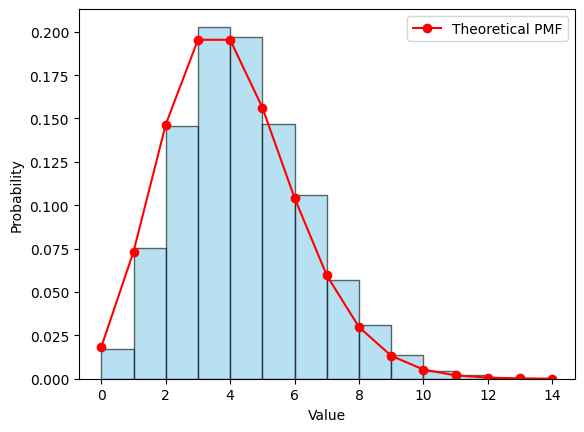

In [6]:
# 5. Create a Python function to generate random samples from a given probability distribution (e.g., binomial, Poisson) and calculate their mean and variance.

import numpy as np
from scipy import stats

def sample_distribution(dist: str, params: dict, size: int = 10000, random_state=None):
    """
    Generate random samples, compute empirical and theoretical statistics.

    Parameters:
        dist (str): 'binomial' or 'poisson'
        params (dict): parameters for the distribution
            - For 'binomial': {'n': int, 'p': float}
            - For 'poisson' : {'mu': float}
        size (int): number of random samples to generate
        random_state (int or None): for reproducibility

    Returns:
        dict: {
          'samples': np.ndarray,
          'empirical_mean': float,
          'empirical_variance': float,
          'theoretical_mean': float,
          'theoretical_variance': float,
          'params': dict # Include params in the return value
        }
    """
    rng = np.random.default_rng(random_state)

    if dist.lower() == 'binomial':
        n = params['n']
        p = params['p']
        samples = rng.binomial(n, p, size=size)
        theoretical_mean = n * p
        theoretical_variance = n * p * (1 - p)
        # 📚 properties: E[X] = np, Var(X) = np(1−p) :contentReference[oaicite:4]{index=4}

    elif dist.lower() == 'poisson':
        mu = params['mu']
        try:
            samples = rng.poisson(mu, size=size)
        except AttributeError:
            # Fallback for older numpy versions if needed
            samples = stats.poisson.rvs(mu, size=size, random_state=random_state)
        theoretical_mean = mu
        theoretical_variance = mu
        # 📚 Poisson: E[X]=Var(X)=λ :contentReference[oaicite:5]{index=5}

    else:
        raise ValueError("Supported distributions: 'binomial', 'poisson'")

    empirical_mean = np.mean(samples)
    empirical_variance = np.var(samples, ddof=0)  # population variance

    return {
        'samples': samples,
        'empirical_mean': empirical_mean,
        'empirical_variance': empirical_variance,
        'theoretical_mean': theoretical_mean,
        'theoretical_variance': theoretical_variance,
        'params': params # Return params
    }

# Pass params when calling the function
result = sample_distribution('binomial', {'n': 10, 'p': 0.3}, size=10000, random_state=123)
print(result['empirical_mean'], result['theoretical_mean'])          # ~3.0
print(result['empirical_variance'], result['theoretical_variance'])  # ~2.1

# Pass params when calling the function
res2 = sample_distribution('poisson', {'mu': 4}, size=10000, random_state=123)
print(res2['empirical_mean'], res2['theoretical_mean'])  # ~4
print(res2['empirical_variance'], res2['theoretical_variance'])  # ~4

import matplotlib.pyplot as plt
from scipy import stats

# Suppose res2 is from a Poisson distribution
data = res2['samples']
x = np.arange(0, data.max() + 1)
# Access params from the returned dictionary
pmf = stats.poisson.pmf(x, mu=res2['params']['mu'])

plt.hist(data, bins=x, density=True, alpha=0.6, color='skyblue', edgecolor='black')
plt.plot(x, pmf, 'ro-', label='Theoretical PMF')
plt.xlabel('Value'); plt.ylabel('Probability')
plt.legend(); plt.show()

In [7]:
# 6. Write a Python script to generate random numbers from a Gaussian (normal) distribution and compute the mean, variance, and standard deviation of the samples.
import numpy as np

def generate_normal_samples(mu: float, sigma: float, size: int, random_state=None):
    """
    Generate samples from a normal distribution and compute stats.

    Args:
        mu (float): mean of the normal distribution
        sigma (float): standard deviation of the normal distribution
        size (int): number of samples
        random_state (int or None): seed for reproducibility

    Returns:
        dict: {
            'samples': ndarray,
            'empirical_mean': float,
            'empirical_variance': float,
            'empirical_std': float,
            'theoretical_mean': float,
            'theoretical_variance': float,
            'theoretical_std': float
        }
    """
    rng = np.random.default_rng(random_state)
    samples = rng.normal(loc=mu, scale=sigma, size=size)

    empirical_mean = np.mean(samples)
    empirical_variance = np.var(samples, ddof=0)   # population variance
    empirical_std = np.std(samples, ddof=0)        # population std

    theoretical_mean = mu
    theoretical_variance = sigma ** 2
    theoretical_std = sigma

    return {
        'samples': samples,
        'empirical_mean': empirical_mean,
        'empirical_variance': empirical_variance,
        'empirical_std': empirical_std,
        'theoretical_mean': theoretical_mean,
        'theoretical_variance': theoretical_variance,
        'theoretical_std': theoretical_std
    }

# Example usage:
if __name__ == "__main__":
    mu = 10
    sigma = 2
    size = 10000

    result = generate_normal_samples(mu, sigma, size, random_state=42)

    print(f"Empirical mean: {result['empirical_mean']:.4f}")
    print(f"Theoretical mean: {result['theoretical_mean']:.4f}")
    print()
    print(f"Empirical variance: {result['empirical_variance']:.4f}")
    print(f"Theoretical variance: {result['theoretical_variance']:.4f}")
    print()
    print(f"Empirical std dev: {result['empirical_std']:.4f}")
    print(f"Theoretical std dev: {result['theoretical_std']:.4f}")


Empirical mean: 9.9795
Theoretical mean: 10.0000

Empirical variance: 4.0504
Theoretical variance: 4.0000

Empirical std dev: 2.0126
Theoretical std dev: 2.0000


   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
Skewness (total_bill): 1.1262
Skewness (tip): 1.4564
total_bill: Positively skewed (right)
tip: Positively skewed (right)
Covariance between total_bill and tip: 8.3235
Pearson correlation between total_bill and tip: 0.6757


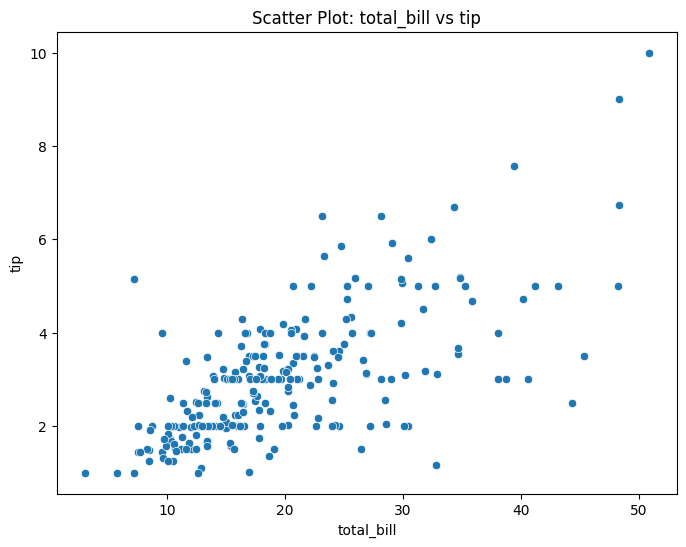

In [8]:
# 7. Use seaborn library to load tips dataset. Find the following from the dataset for the columns total_bill and tip`:



# (i) Write a Python function that calculates their skewness.


# (ii) Create a program that determines whether the columns exhibit positive skewness, negative skewness, or is
# approximately symmetric.


# (iii) Write a function that calculates the covariance between two columns.


# (iv) Implement a Python program that calculates the Pearson correlation coefficient between two columns.


# (v) Write a script to visualize the correlation between two specific columns in a Pandas DataFrame using
# scatter plots.


# Step 1: Load the tips dataset

import seaborn as sns
import pandas as pd

# Load the dataset
tips = sns.load_dataset("tips")
print(tips.head())


# Step 2: Function to calculate skewness

from scipy.stats import skew

def calculate_skewness(series: pd.Series) -> float:
    """Calculate skewness of a Pandas Series."""
    return skew(series)

skew_total_bill = calculate_skewness(tips['total_bill'])
skew_tip = calculate_skewness(tips['tip'])
print(f"Skewness (total_bill): {skew_total_bill:.4f}")
print(f"Skewness (tip): {skew_tip:.4f}")


# Step 3: Determine skewness type

def skewness_type(skew_value: float, tol: float = 0.1) -> str:
    """Determine if skewness is positive, negative or symmetric."""
    if skew_value > tol:
        return "Positively skewed (right)"
    elif skew_value < -tol:
        return "Negatively skewed (left)"
    else:
        return "Approximately symmetric"

print("total_bill:", skewness_type(skew_total_bill))
print("tip:", skewness_type(skew_tip))


# Step 4: Function to calculate covariance

def covariance(series1: pd.Series, series2: pd.Series) -> float:
    """Calculate covariance between two Series."""
    return series1.cov(series2)

cov = covariance(tips['total_bill'], tips['tip'])
print(f"Covariance between total_bill and tip: {cov:.4f}")


# Step 5: Calculate Pearson correlation coefficient

def pearson_corr(series1: pd.Series, series2: pd.Series) -> float:
    """Calculate Pearson correlation coefficient."""
    return series1.corr(series2)

corr = pearson_corr(tips['total_bill'], tips['tip'])
print(f"Pearson correlation between total_bill and tip: {corr:.4f}")

# Step 6: Visualize with scatter plot


import matplotlib.pyplot as plt

def plot_scatter(df: pd.DataFrame, col1: str, col2: str):
    """Plot scatter plot between two columns."""
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=df, x=col1, y=col2)
    plt.title(f"Scatter Plot: {col1} vs {col2}")
    plt.show()

# Call it:
plot_scatter(tips, 'total_bill', 'tip')


In [9]:
# 8. Write a Python function to calculate the probability density function (PDF) of a continuous randomvariable for a given normal distribution.

import math

def normal_pdf(x: float, mu: float, sigma: float) -> float:
    """
    Calculate the PDF of a normal distribution at point x.

    Parameters:
        x (float): The point at which to evaluate the PDF
        mu (float): The mean of the normal distribution
        sigma (float): The standard deviation of the normal distribution

    Returns:
        float: The probability density at x
    """
    if sigma <= 0:
        raise ValueError("Standard deviation must be positive.")

    coef = 1 / (sigma * math.sqrt(2 * math.pi))
    exponent = -0.5 * ((x - mu) / sigma) ** 2
    return coef * math.exp(exponent)

# Example: standard normal at x = 0
result = normal_pdf(0, mu=0, sigma=1)
print(f"PDF at x=0 for N(0,1): {result:.5f}")

# Example: N(5, 2^2) at x = 6
result2 = normal_pdf(6, mu=5, sigma=2)
print(f"PDF at x=6 for N(5,4): {result2:.5f}")


PDF at x=0 for N(0,1): 0.39894
PDF at x=6 for N(5,4): 0.17603


In [10]:
# 9. Create a program to calculate the cumulative distribution function (CDF) of exponential distribution.

import math

def exponential_cdf(x: float, lambd: float) -> float:
    """
    Calculate the CDF of the Exponential distribution at point x.

    Parameters:
        x (float): The point at which to evaluate the CDF (x >= 0)
        lambd (float): The rate parameter λ (must be > 0)

    Returns:
        float: The probability that X <= x
    """
    if lambd <= 0:
        raise ValueError("Rate parameter lambda must be positive.")
    if x < 0:
        return 0.0  # The CDF is zero for x < 0

    return 1 - math.exp(-lambd * x)

# Example: lambda = 0.5, x = 2
result = exponential_cdf(2, lambd=0.5)
print(f"CDF at x=2 for Exp(0.5): {result:.5f}")


from scipy.stats import expon

lambd = 0.5
scale = 1 / lambd  # In scipy, scale = 1/lambda
x = 2

# SciPy CDF
result_scipy = expon.cdf(x, scale=scale)
print(f"SciPy CDF: {result_scipy:.5f}")


CDF at x=2 for Exp(0.5): 0.63212
SciPy CDF: 0.63212


In [11]:
# 10. Write a Python function to calculate the probability mass function (PMF) of Poisson distribution.

import math

def poisson_pmf(k: int, lambd: float) -> float:
    """
    Calculate the PMF of the Poisson distribution at integer k.

    Parameters:
        k (int): Number of occurrences (k >= 0)
        lambd (float): Rate parameter λ (must be > 0)

    Returns:
        float: P(X = k)
    """
    if lambd <= 0:
        raise ValueError("Rate parameter λ must be positive.")
    if k < 0:
        return 0.0

    return (math.exp(-lambd) * lambd**k) / math.factorial(k)

# Example: λ = 3, k = 2
result = poisson_pmf(2, lambd=3)
print(f"P(X=2) for Poisson(λ=3): {result:.5f}")


from scipy.stats import poisson

lambd = 3
k = 2

result_scipy = poisson.pmf(k, mu=lambd)
print(f"SciPy PMF: {result_scipy:.5f}")


P(X=2) for Poisson(λ=3): 0.22404
SciPy PMF: 0.22404


In [12]:
# 11. A company wants to test if a new website layout leads to a higher conversion rate (percentage of visitors
# who make a purchase). They collect data from the old and new layouts to compare.


# To generate the data use the following command:

# ```python

# import numpy as np

# # 50 purchases out of 1000 visitors

# old_layout = np.array([1] * 50 + [0] * 950)

# # 70 purchases out of 1000 visitors

# new_layout = np.array([1] * 70 + [0] * 930)

#   ```

# Apply z-test to find which layout is successful.

import numpy as np

old_layout = np.array([1] * 50 + [0] * 950)
new_layout = np.array([1] * 70 + [0] * 930)


import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# Given data
old_layout = np.array([1] * 50 + [0] * 950)
new_layout = np.array([1] * 70 + [0] * 930)

# Number of successes
x1 = old_layout.sum()
x2 = new_layout.sum()

# Number of trials
n1 = len(old_layout)
n2 = len(new_layout)

# Proportions
p1 = x1 / n1
p2 = x2 / n2

print(f"Old layout conversion rate: {p1:.4f}")
print(f"New layout conversion rate: {p2:.4f}")

# Pooled proportion
p_pool = (x1 + x2) / (n1 + n2)

# Standard error
se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))

# Z-statistic
z = (p1 - p2) / se

# Two-tailed p-value
from scipy.stats import norm
p_value = 2 * (1 - norm.cdf(abs(z)))

print(f"Z-statistic: {z:.4f}")
print(f"P-value: {p_value:.4f}")

# Check with statsmodels for convenience
count = np.array([x1, x2])
nobs = np.array([n1, n2])
z_stat, pval = proportions_ztest(count, nobs)
print(f"Z-statistic (statsmodels): {z_stat:.4f}")
print(f"P-value (statsmodels): {pval:.4f}")

# Interpretation
alpha = 0.05
if pval < alpha:
    print("Reject H0: There is a significant difference in conversion rates.")
else:
    print("Fail to reject H0: No significant difference in conversion rates.")



ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
# 12. A tutoring service claims that its program improves students' exam scores. A sample of students who
# participated in the program was taken, and their scores before and after the program were recorded.


# Use the below code to generate samples of respective arrays of marks:

# ```python

# before_program = np.array([75, 80, 85, 70, 90, 78, 92, 88, 82, 87])

# after_program = np.array([80, 85, 90, 80, 92, 80, 95, 90, 85, 88])

# ```

# Use z-test to find if the claims made by tutor are true or false.

import numpy as np

before_program = np.array([75, 80, 85, 70, 90, 78, 92, 88, 82, 87])
after_program = np.array([80, 85, 90, 80, 92, 80, 95, 90, 85, 88])


diff = after_program - before_program
print("Differences:", diff)


import numpy as np
from scipy.stats import norm

# Data
before_program = np.array([75, 80, 85, 70, 90, 78, 92, 88, 82, 87])
after_program = np.array([80, 85, 90, 80, 92, 80, 95, 90, 85, 88])

# Paired differences
diff = after_program - before_program
n = len(diff)

# Sample mean & std dev of differences
mean_diff = np.mean(diff)
std_diff = np.std(diff, ddof=1)  # sample standard deviation

# Z-statistic
se = std_diff / np.sqrt(n)
z = (mean_diff - 0) / se

# One-tailed p-value (H1: mean_diff > 0)
p_value = 1 - norm.cdf(z)

print(f"Mean difference: {mean_diff:.4f}")
print(f"Standard deviation of differences: {std_diff:.4f}")
print(f"Z-statistic: {z:.4f}")
print(f"P-value: {p_value:.4f}")

# Decision
alpha = 0.05
if p_value < alpha:
    print("Reject H0: The tutoring program significantly improved scores.")
else:
    print("Fail to reject H0: No significant improvement found.")


In [ ]:
# 13. A pharmaceutical company wants to determine if a new drug is effective in reducing blood pressure. They
# conduct a study and record blood pressure measurements before and after administering the drug.


# Use the below code to generate samples of respective arrays of blood pressure:


# ```python

# before_drug = np.array([145, 150, 140, 135, 155, 160, 152, 148, 130, 138])

# after_drug = np.array([130, 140, 132, 128, 145, 148, 138, 136, 125, 130])

#   ```


# Implement z-test to find if the drug really works or not

import numpy as np

before_drug = np.array([145, 150, 140, 135, 155, 160, 152, 148, 130, 138])
after_drug = np.array([130, 140, 132, 128, 145, 148, 138, 136, 125, 130])

diff = after_drug - before_drug
print("Differences:", diff)


import numpy as np
from scipy.stats import norm

# Data
before_drug = np.array([145, 150, 140, 135, 155, 160, 152, 148, 130, 138])
after_drug = np.array([130, 140, 132, 128, 145, 148, 138, 136, 125, 130])

# Paired differences (after - before)
diff = after_drug - before_drug
n = len(diff)

# Mean and std dev of differences
mean_diff = np.mean(diff)
std_diff = np.std(diff, ddof=1)  # sample standard deviation

# Standard error
se = std_diff / np.sqrt(n)

# Z-statistic
z = (mean_diff - 0) / se

# One-tailed p-value (H1: mean difference < 0)
p_value = norm.cdf(z)

print(f"Differences: {diff}")
print(f"Mean difference: {mean_diff:.4f}")
print(f"Standard deviation of differences: {std_diff:.4f}")
print(f"Z-statistic: {z:.4f}")
print(f"P-value: {p_value:.4f}")

# Decision
alpha = 0.05
if p_value < alpha:
    print("Reject H0: The drug significantly reduces blood pressure.")
else:
    print("Fail to reject H0: No significant reduction in blood pressure found.")


In [ ]:
# 14. A customer service department claims that their average response time is less than 5 minutes. A sample
# of recent customer interactions was taken, and the response times were recorded.


# Implement the below code to generate the array of response time:

# ```python

# response_times = np.array([4.3, 3.8, 5.1, 4.9, 4.7, 4.2, 5.2, 4.5, 4.6, 4.4])

# ```

# Implement z-test to find the claims made by customer service department are tru or false.


import numpy as np

response_times = np.array([4.3, 3.8, 5.1, 4.9, 4.7, 4.2, 5.2, 4.5, 4.6, 4.4])


import numpy as np
from scipy.stats import norm

# Data
response_times = np.array([4.3, 3.8, 5.1, 4.9, 4.7, 4.2, 5.2, 4.5, 4.6, 4.4])

# Hypothesized population mean
mu0 = 5

# Sample stats
n = len(response_times)
x_bar = np.mean(response_times)
s = np.std(response_times, ddof=1)  # sample standard deviation

# Standard error
se = s / np.sqrt(n)

# Z-statistic
z = (x_bar - mu0) / se

# One-tailed p-value (H1: mean < mu0)
p_value = norm.cdf(z)

print(f"Sample mean: {x_bar:.4f}")
print(f"Sample std dev: {s:.4f}")
print(f"Z-statistic: {z:.4f}")
print(f"P-value: {p_value:.4f}")

# Decision
alpha = 0.05
if p_value < alpha:
    print("Reject H0: The customer service claim is true (response time < 5 min).")
else:
    print("Fail to reject H0: Not enough evidence to support the claim.")


In [ ]:
# 15. A company is testing two different website layouts to see which one leads to higher click-through rates.
# Write a Python function to perform an A/B test analysis, including calculating the t-statistic, degrees of
# freedom, and p-value.


# Use the following data:

# ```python

# layout_a_clicks = [28, 32, 33, 29, 31, 34, 30, 35, 36, 37]

# layout_b_clicks = [40, 41, 38, 42, 39, 44, 43, 41, 45, 47]

import numpy as np
from scipy.stats import t

def ab_test_analysis(group1, group2):
    """
    Perform an A/B test: two-sample t-test (Welch's t-test) for unequal variances.

    Args:
        group1 (list or array): Sample data for layout A
        group2 (list or array): Sample data for layout B

    Returns:
        dict: t-statistic, degrees of freedom, p-value
    """
    group1 = np.array(group1)
    group2 = np.array(group2)

    n1 = len(group1)
    n2 = len(group2)

    mean1 = np.mean(group1)
    mean2 = np.mean(group2)

    var1 = np.var(group1, ddof=1)
    var2 = np.var(group2, ddof=1)

    # Standard error
    se = np.sqrt(var1/n1 + var2/n2)

    # t-statistic
    t_stat = (mean1 - mean2) / se

    # Degrees of freedom (Welch-Satterthwaite)
    df = (var1/n1 + var2/n2)**2 / ((var1**2)/((n1**2)*(n1-1)) + (var2**2)/((n2**2)*(n2-1)))

    # Two-tailed p-value
    p_value = 2 * t.cdf(-abs(t_stat), df)

    return {
        'mean_group1': mean1,
        'mean_group2': mean2,
        't_statistic': t_stat,
        'degrees_of_freedom': df,
        'p_value': p_value
    }

# Example usage:
layout_a_clicks = [28, 32, 33, 29, 31, 34, 30, 35, 36, 37]
layout_b_clicks = [40, 41, 38, 42, 39, 44, 43, 41, 45, 47]

result = ab_test_analysis(layout_a_clicks, layout_b_clicks)

print(f"Mean Layout A: {result['mean_group1']:.2f}")
print(f"Mean Layout B: {result['mean_group2']:.2f}")
print(f"t-statistic: {result['t_statistic']:.4f}")
print(f"Degrees of freedom: {result['degrees_of_freedom']:.2f}")
print(f"p-value: {result['p_value']:.4f}")

if result['p_value'] < 0.05:
    print("Reject H0: Significant difference between layouts.")
else:
    print("Fail to reject H0: No significant difference found.")


In [ ]:
# 16. A pharmaceutical company wants to determine if a new drug is more effective than an existing drug in
# reducing cholesterol levels. Create a program to analyze the clinical trial data and calculate the tstatistic and p-value for the treatment effect.


# Use the following data of cholestrol level:

# ```python

# existing_drug_levels = [180, 182, 175, 185, 178, 176, 172, 184, 179, 183]

# new_drug_levels = [170, 172, 165, 168, 175, 173, 170, 178, 172, 176]


existing_drug_levels = [180, 182, 175, 185, 178, 176, 172, 184, 179, 183]
new_drug_levels = [170, 172, 165, 168, 175, 173, 170, 178, 172, 176]

import numpy as np
from scipy.stats import t

def analyze_treatment_effect(group1, group2):
    """
    Perform a one-tailed Welch's t-test to test if group2 < group1.

    Args:
        group1: Existing drug levels.
        group2: New drug levels.
    Returns:
        dict: t-statistic, degrees of freedom, p-value.
    """
    group1 = np.array(group1)
    group2 = np.array(group2)

    n1 = len(group1)
    n2 = len(group2)

    mean1 = np.mean(group1)
    mean2 = np.mean(group2)

    var1 = np.var(group1, ddof=1)
    var2 = np.var(group2, ddof=1)

    # Standard error
    se = np.sqrt(var1/n1 + var2/n2)

    # t-statistic
    t_stat = (mean1 - mean2) / se

    # Degrees of freedom (Welch–Satterthwaite)
    df_num = (var1/n1 + var2/n2)**2
    df_den = ((var1/n1)**2)/(n1-1) + ((var2/n2)**2)/(n2-1)
    df = df_num / df_den

    # One-tailed p-value: H1: mean2 < mean1 => mean1 - mean2 > 0
    p_value = 1 - t.cdf(t_stat, df)

    return {
        'mean_existing': mean1,
        'mean_new': mean2,
        't_statistic': t_stat,
        'degrees_of_freedom': df,
        'p_value': p_value
    }

# Given data
existing_drug_levels = [180, 182, 175, 185, 178, 176, 172, 184, 179, 183]
new_drug_levels = [170, 172, 165, 168, 175, 173, 170, 178, 172, 176]

result = analyze_treatment_effect(existing_drug_levels, new_drug_levels)

print(f"Mean Existing Drug: {result['mean_existing']:.2f}")
print(f"Mean New Drug: {result['mean_new']:.2f}")
print(f"t-statistic: {result['t_statistic']:.4f}")
print(f"Degrees of freedom: {result['degrees_of_freedom']:.2f}")
print(f"P-value: {result['p_value']:.4f}")

alpha = 0.05
if result['p_value'] < alpha:
    print("Reject H0: The new drug significantly lowers cholesterol more than the existing drug.")
else:
    print("Fail to reject H0: Not enough evidence that the new drug is more effective.")



In [ ]:
# 17. A school district introduces an educational intervention program to improve math scores. Write a Python
# function to analyze pre- and post-intervention test scores, calculating the t-statistic and p-value to
# determine if the intervention had a significant impact.


# Use the following data of test score:


#   ```python

#   pre_intervention_scores = [80, 85, 90, 75, 88, 82, 92, 78, 85, 87]

#   post_intervention_scores = [90, 92, 88, 92, 95, 91, 96, 93, 89, 93]

pre_intervention_scores = [80, 85, 90, 75, 88, 82, 92, 78, 85, 87]
post_intervention_scores = [90, 92, 88, 92, 95, 91, 96, 93, 89, 93]

import numpy as np
from scipy.stats import t as t_dist

def analyze_intervention(pre_scores, post_scores):
    """
    Perform a paired t-test to check if post-intervention scores improved.

    Args:
        pre_scores: list or array of scores before the intervention
        post_scores: list or array of scores after the intervention

    Returns:
        dict: mean_diff, t_statistic, degrees_of_freedom, p_value
    """
    pre_scores = np.array(pre_scores)
    post_scores = np.array(post_scores)

    diff = post_scores - pre_scores
    n = len(diff)

    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)

    se = std_diff / np.sqrt(n)

    t_stat = (mean_diff - 0) / se

    df = n - 1

    # One-tailed p-value (H1: mean_diff > 0)
    p_value = 1 - t_dist.cdf(t_stat, df)

    return {
        'mean_difference': mean_diff,
        't_statistic': t_stat,
        'degrees_of_freedom': df,
        'p_value': p_value
    }

# Example usage:
pre_intervention_scores = [80, 85, 90, 75, 88, 82, 92, 78, 85, 87]
post_intervention_scores = [90, 92, 88, 92, 95, 91, 96, 93, 89, 93]

result = analyze_intervention(pre_intervention_scores, post_intervention_scores)

print(f"Mean difference: {result['mean_difference']:.2f}")
print(f"t-statistic: {result['t_statistic']:.4f}")
print(f"Degrees of freedom: {result['degrees_of_freedom']}")
print(f"P-value: {result['p_value']:.4f}")

alpha = 0.05
if result['p_value'] < alpha:
    print("Reject H0: The intervention significantly improved math scores.")
else:
    print("Fail to reject H0: No significant improvement detected.")



In [ ]:
# 18. An HR department wants to investigate if there's a gender-based salary gap within the company. Develop
# a program to analyze salary data, calculate the t-statistic, and determine if there's a statistically
# significant difference between the average salaries of male and female employees.


# Use the below code to generate synthetic data:


# ```python

# # Generate synthetic salary data for male and female employees

# np.random.seed(0)  # For reproducibility

# male_salaries = np.random.normal(loc=50000, scale=10000, size=20)

# female_salaries = np.random.normal(loc=55000, scale=9000, size=20)
# ```

import numpy as np

np.random.seed(0)  # For reproducibility

male_salaries = np.random.normal(loc=50000, scale=10000, size=20)
female_salaries = np.random.normal(loc=55000, scale=9000, size=20)

import numpy as np
from scipy.stats import t

def analyze_gender_salary_gap(male_salaries, female_salaries):
    """
    Perform a two-sample Welch's t-test to test if there's a gender-based salary difference.

    Args:
        male_salaries: list or array of male salaries
        female_salaries: list or array of female salaries

    Returns:
        dict: mean_male, mean_female, t_statistic, degrees_of_freedom, p_value
    """
    male_salaries = np.array(male_salaries)
    female_salaries = np.array(female_salaries)

    n1 = len(male_salaries)
    n2 = len(female_salaries)

    mean1 = np.mean(male_salaries)
    mean2 = np.mean(female_salaries)

    var1 = np.var(male_salaries, ddof=1)
    var2 = np.var(female_salaries, ddof=1)

    se = np.sqrt(var1/n1 + var2/n2)

    t_stat = (mean1 - mean2) / se

    # Degrees of freedom
    df_num = (var1/n1 + var2/n2)**2
    df_den = ((var1/n1)**2)/(n1-1) + ((var2/n2)**2)/(n2-1)
    df = df_num / df_den

    # Two-tailed p-value
    p_value = 2 * t.cdf(-abs(t_stat), df)

    return {
        'mean_male': mean1,
        'mean_female': mean2,
        't_statistic': t_stat,
        'degrees_of_freedom': df,
        'p_value': p_value
    }

# Example usage:
np.random.seed(0)
male_salaries = np.random.normal(loc=50000, scale=10000, size=20)
female_salaries = np.random.normal(loc=55000, scale=9000, size=20)

result = analyze_gender_salary_gap(male_salaries, female_salaries)

print(f"Mean Male Salary: ${result['mean_male']:.2f}")
print(f"Mean Female Salary: ${result['mean_female']:.2f}")
print(f"t-statistic: {result['t_statistic']:.4f}")
print(f"Degrees of freedom: {result['degrees_of_freedom']:.2f}")
print(f"P-value: {result['p_value']:.4f}")

alpha = 0.05
if result['p_value'] < alpha:
    print("Reject H0: There is a significant gender-based salary difference.")
else:
    print("Fail to reject H0: No significant gender-based salary difference found.")


In [ ]:
# 19. A manufacturer produces two different versions of a product and wants to compare their quality scores.
# Create a Python function to analyze quality assessment data, calculate the t-statistic, and decide
# whether there's a significant difference in quality between the two versions.


# Use the following data:


# ```python

# version1_scores = [85, 88, 82, 89, 87, 84, 90, 88, 85, 86, 91, 83, 87, 84, 89, 86, 84, 88, 85, 86, 89, 90, 87, 88, 85]

# version2_scores = [80, 78, 83, 81, 79, 82, 76, 80, 78, 81, 77, 82, 80, 79, 82, 79, 80, 81, 79, 82, 79, 78, 80, 81, 82]
# ```


version1_scores = [
    85, 88, 82, 89, 87, 84, 90, 88, 85, 86,
    91, 83, 87, 84, 89, 86, 84, 88, 85, 86,
    89, 90, 87, 88, 85
]

version2_scores = [
    80, 78, 83, 81, 79, 82, 76, 80, 78, 81,
    77, 82, 80, 79, 82, 79, 80, 81, 79, 82,
    79, 78, 80, 81, 82
]


import numpy as np
from scipy.stats import t

def compare_product_versions(version1, version2):
    """
    Perform a two-sample Welch's t-test to compare product version quality scores.

    Args:
        version1: list or array of scores for version 1
        version2: list or array of scores for version 2

    Returns:
        dict: mean_version1, mean_version2, t_statistic, degrees_of_freedom, p_value
    """
    version1 = np.array(version1)
    version2 = np.array(version2)

    n1 = len(version1)
    n2 = len(version2)

    mean1 = np.mean(version1)
    mean2 = np.mean(version2)

    var1 = np.var(version1, ddof=1)
    var2 = np.var(version2, ddof=1)

    # Standard error
    se = np.sqrt(var1/n1 + var2/n2)

    # t-statistic
    t_stat = (mean1 - mean2) / se

    # Degrees of freedom
    df_num = (var1/n1 + var2/n2)**2
    df_den = ((var1/n1)**2)/(n1-1) + ((var2/n2)**2)/(n2-1)
    df = df_num / df_den

    # Two-tailed p-value
    p_value = 2 * t.cdf(-abs(t_stat), df)

    return {
        'mean_version1': mean1,
        'mean_version2': mean2,
        't_statistic': t_stat,
        'degrees_of_freedom': df,
        'p_value': p_value
    }

# Example usage:
version1_scores = [85, 88, 82, 89, 87, 84, 90, 88, 85, 86, 91, 83, 87, 84, 89, 86, 84, 88, 85, 86, 89, 90, 87, 88, 85]
version2_scores = [80, 78, 83, 81, 79, 82, 76, 80, 78, 81, 77, 82, 80, 79, 82, 79, 80, 81, 79, 82, 79, 78, 80, 81, 82]

result = compare_product_versions(version1_scores, version2_scores)

print(f"Mean Version 1: {result['mean_version1']:.2f}")
print(f"Mean Version 2: {result['mean_version2']:.2f}")
print(f"t-statistic: {result['t_statistic']:.4f}")
print(f"Degrees of freedom: {result['degrees_of_freedom']:.2f}")
print(f"P-value: {result['p_value']:.4f}")

alpha = 0.05
if result['p_value'] < alpha:
    print("Reject H0: There is a significant difference in quality between the two versions.")
else:
    print("Fail to reject H0: No significant difference in quality found.")


In [ ]:
# 20. A restaurant chain collects customer satisfaction scores for two different branches. Write a program to
# analyze the scores, calculate the t-statistic, and determine if there's a statistically significant difference in
# customer satisfaction between the branches.


# Use the below data of scores:

#   ```python

# branch_a_scores = [4, 5, 3, 4, 5, 4, 5, 3, 4, 4, 5, 4, 4, 3, 4, 5, 5, 4, 3, 4, 5, 4, 3, 5, 4, 4, 5, 3, 4, 5, 4]

# branch_b_scores = [3, 4, 2, 3, 4, 3, 4, 2, 3, 3, 4, 3, 3, 2, 3, 4, 4, 3, 2, 3, 4, 3, 2, 4, 3, 3, 4, 2, 3, 4, 3]
#  ```

branch_a_scores = [
    4, 5, 3, 4, 5, 4, 5, 3, 4, 4, 5, 4, 4, 3, 4,
    5, 5, 4, 3, 4, 5, 4, 3, 5, 4, 4, 5, 3, 4, 5, 4
]

branch_b_scores = [
    3, 4, 2, 3, 4, 3, 4, 2, 3, 3, 4, 3, 3, 2, 3,
    4, 4, 3, 2, 3, 4, 3, 2, 4, 3, 3, 4, 2, 3, 4, 3
]

import numpy as np
from scipy.stats import t

def analyze_branch_satisfaction(branch_a, branch_b):
    """
    Perform a two-sample Welch's t-test to compare customer satisfaction.

    Args:
        branch_a: list or array of scores for Branch A
        branch_b: list or array of scores for Branch B

    Returns:
        dict: means, t-statistic, degrees of freedom, p-value
    """
    branch_a = np.array(branch_a)
    branch_b = np.array(branch_b)

    n1 = len(branch_a)
    n2 = len(branch_b)

    mean1 = np.mean(branch_a)
    mean2 = np.mean(branch_b)

    var1 = np.var(branch_a, ddof=1)
    var2 = np.var(branch_b, ddof=1)

    se = np.sqrt(var1/n1 + var2/n2)

    t_stat = (mean1 - mean2) / se

    df_num = (var1/n1 + var2/n2)**2
    df_den = ((var1/n1)**2)/(n1-1) + ((var2/n2)**2)/(n2-1)
    df = df_num / df_den

    p_value = 2 * t.cdf(-abs(t_stat), df)

    return {
        'mean_branch_a': mean1,
        'mean_branch_b': mean2,
        't_statistic': t_stat,
        'degrees_of_freedom': df,
        'p_value': p_value
    }

# Given data
branch_a_scores = [4, 5, 3, 4, 5, 4, 5, 3, 4, 4, 5, 4, 4, 3, 4, 5, 5, 4, 3, 4, 5, 4, 3, 5, 4, 4, 5, 3, 4, 5, 4]
branch_b_scores = [3, 4, 2, 3, 4, 3, 4, 2, 3, 3, 4, 3, 3, 2, 3, 4, 4, 3, 2, 3, 4, 3, 2, 4, 3, 3, 4, 2, 3, 4, 3]

result = analyze_branch_satisfaction(branch_a_scores, branch_b_scores)

print(f"Mean Branch A: {result['mean_branch_a']:.2f}")
print(f"Mean Branch B: {result['mean_branch_b']:.2f}")
print(f"t-statistic: {result['t_statistic']:.4f}")
print(f"Degrees of freedom: {result['degrees_of_freedom']:.2f}")
print(f"P-value: {result['p_value']:.4f}")

alpha = 0.05
if result['p_value'] < alpha:
    print("Reject H0: There is a significant difference in customer satisfaction between the branches.")
else:
    print("Fail to reject H0: No significant difference in satisfaction found.")




In [ ]:
# 21. A political analyst wants to determine if there is a significant association between age groups and voter
# preferences (Candidate A or Candidate B). They collect data from a sample of 500 voters and classify
# them into different age groups and candidate preferences. Perform a Chi-Square test to determine if
# there is a significant association between age groups and voter preferences.


# Use the below code to generate data:

# ```python

# np.random.seed(0)

# age_groups = np.random.choice([ 18 30 , 31 50 , 51+', 51+'], size=30)

# voter_preferences = np.random.choice(['Candidate A', 'Candidate B'], size=30)
# ```





In [ ]:
# 22. A company conducted a customer satisfaction survey to determine if there is a significant relationship
# between product satisfaction levels (Satisfied, Neutral, Dissatisfied) and the region where customers are
# located (East, West, North, South). The survey data is summarized in a contingency table. Conduct a ChiSquare test to determine if there is a significant relationship between product satisfaction levels and
# customer regions.


# Sample data:

# ```python

# #Sample data: Product satisfaction levels (rows) vs. Customer regions (columns)

# data = np.array([[50, 30, 40, 20], [30, 40, 30, 50], [20, 30, 40, 30]])

# ```

import numpy as np

np.random.seed(0)

age_groups = np.random.choice(['18-30', '31-50', '51+'], size=30)
voter_preferences = np.random.choice(['Candidate A', 'Candidate B'], size=30)

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Generate data
np.random.seed(0)
age_groups = np.random.choice(['18-30', '31-50', '51+'], size=30)
voter_preferences = np.random.choice(['Candidate A', 'Candidate B'], size=30)

# 2. Create a DataFrame
df = pd.DataFrame({
    'Age Group': age_groups,
    'Voter Preference': voter_preferences
})

print("Sample Data:")
print(df.head())

# 3. Create a contingency table
contingency_table = pd.crosstab(df['Age Group'], df['Voter Preference'])
print("\nContingency Table:")
print(contingency_table)

# 4. Perform Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p:.4f}")
print("\nExpected Frequencies:")
print(expected)

# 5. Conclusion
alpha = 0.05
if p < alpha:
    print("\nReject H0: There is a significant association between age group and voter preference.")
else:
    print("\nFail to reject H0: No significant association found.")



In [ ]:
# 23. A company implemented an employee training program to improve job performance (Effective, Neutral,
# Ineffective). After the training, they collected data from a sample of employees and classified them based
# on their job performance before and after the training. Perform a Chi-Square test to determine if there is a
# significant difference between job performance levels before and after the training.


# Sample data:

# ```python

# # Sample data: Job performance levels before (rows) and after (columns) training

# data = np.array([[50, 30, 20], [30, 40, 30], [20, 30, 40]])

# ```

import numpy as np
from scipy.stats import chi2_contingency

# Given data
data = np.array([
    [50, 30, 20],
    [30, 40, 30],
    [20, 30, 40]
])

print("Observed Frequencies:")
print(data)

# Perform Chi-Square test
chi2, p, dof, expected = chi2_contingency(data)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p:.4f}")

print("\nExpected Frequencies:")
print(expected)

# Conclusion
alpha = 0.05
if p < alpha:
    print("\nReject H0: There is a significant association between job performance before and after training.")
else:
    print("\nFail to reject H0: No significant association found. The training may not have made a difference.")



In [ ]:
# 24. A company produces three different versions of a product: Standard, Premium, and Deluxe. The
# company wants to determine if there is a significant difference in customer satisfaction scores among the
# three product versions. They conducted a survey and collected customer satisfaction scores for each
# version from a random sample of customers. Perform an ANOVA test to determine if there is a significant
# difference in customer satisfaction scores.


#   Use the following data:

#   ```python

#   # Sample data: Customer satisfaction scores for each product version

#   standard_scores = [80, 85, 90, 78, 88, 82, 92, 78, 85, 87]

#   premium_scores = [90, 92, 88, 92, 95, 91, 96, 93, 89, 93]

#   deluxe_scores = [95, 98, 92, 97, 96, 94, 98, 97, 92, 99]

#   ``


# Satisfaction scores for each version
standard_scores = [80, 85, 90, 78, 88, 82, 92, 78, 85, 87]
premium_scores  = [90, 92, 88, 92, 95, 91, 96, 93, 89, 93]
deluxe_scores   = [95, 98, 92, 97, 96, 94, 98, 97, 92, 99]


import numpy as np
from scipy.stats import f_oneway

# Data
standard_scores = [80, 85, 90, 78, 88, 82, 92, 78, 85, 87]
premium_scores  = [90, 92, 88, 92, 95, 91, 96, 93, 89, 93]
deluxe_scores   = [95, 98, 92, 97, 96, 94, 98, 97, 92, 99]

# Perform one-way ANOVA
f_statistic, p_value = f_oneway(standard_scores, premium_scores, deluxe_scores)

print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret result
alpha = 0.05
if p_value < alpha:
    print("\nReject H0: There is a significant difference in customer satisfaction among the product versions.")
else:
    print("\nFail to reject H0: No significant difference in satisfaction among the product versions.")

